In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_uber = pd.read_csv('ncr_ride_bookings.csv')

In [2]:
df_uber.head(3)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card


In [3]:
df_uber.columns.values

array(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype=object)

In [4]:
valores_nulos = df_uber.isnull().sum()

porcentaje_nulos = (valores_nulos / len(df_uber)) * 100

In [20]:
dict_nulos = {'columna': valores_nulos.index, 'Porcentaje_nulos': porcentaje_nulos.values}
nulos_df = pd.DataFrame(dict_nulos)
nulos_df = nulos_df[nulos_df['Porcentaje_nulos'] > 0]

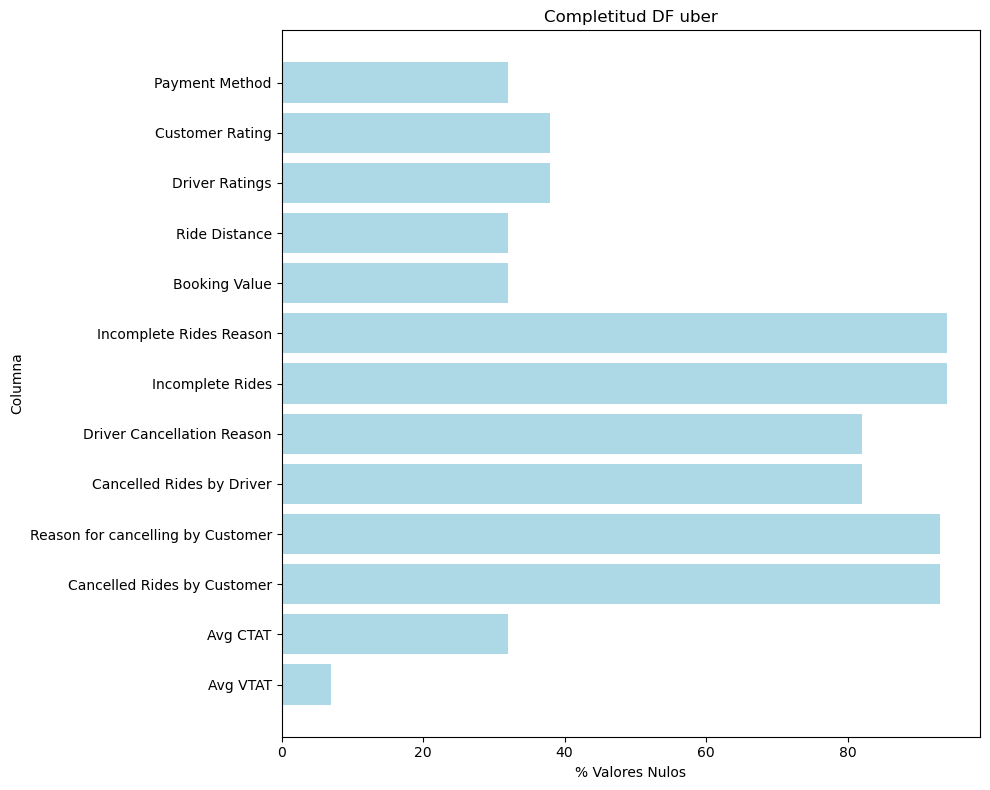

In [23]:
# Graficar completitud
plt.figure(figsize = (10,8))
plt.barh(nulos_df['columna'], nulos_df['Porcentaje_nulos'], color = 'lightblue')
plt.title("Completitud DF uber")
plt.xlabel("% Valores Nulos")
plt.ylabel('Columna')
plt.tight_layout()
plt.show()

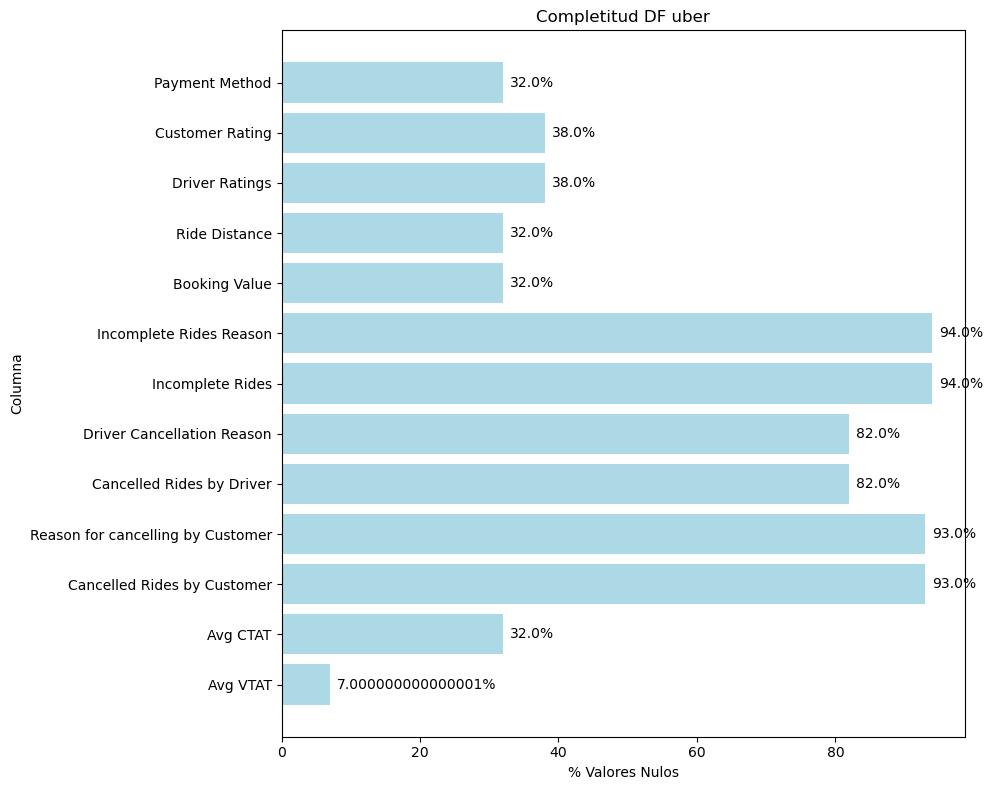

In [29]:
plt.figure(figsize = (10,8))
bars = plt.barh(nulos_df['columna'], nulos_df['Porcentaje_nulos'], color = 'lightblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:}%', va = 'center')


plt.title("Completitud DF uber")
plt.xlabel("% Valores Nulos")
plt.ylabel('Columna')
plt.tight_layout()
plt.show()

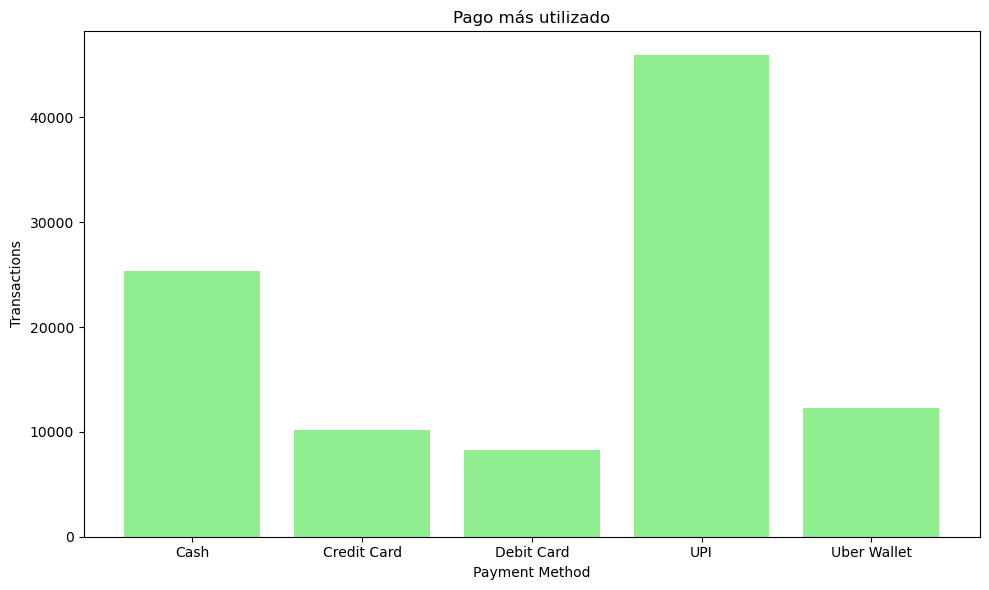

In [33]:
payment_values = df_uber.groupby(['Payment Method'], as_index = False)['Customer ID'].count()

plt.figure(figsize = (10,6))
plt.bar(payment_values['Payment Method'], payment_values['Customer ID'], color = 'lightgreen')
plt.title('Pago más utilizado')
plt.xlabel('Payment Method')
plt.ylabel('Transactions')
plt.tight_layout()
plt.show()

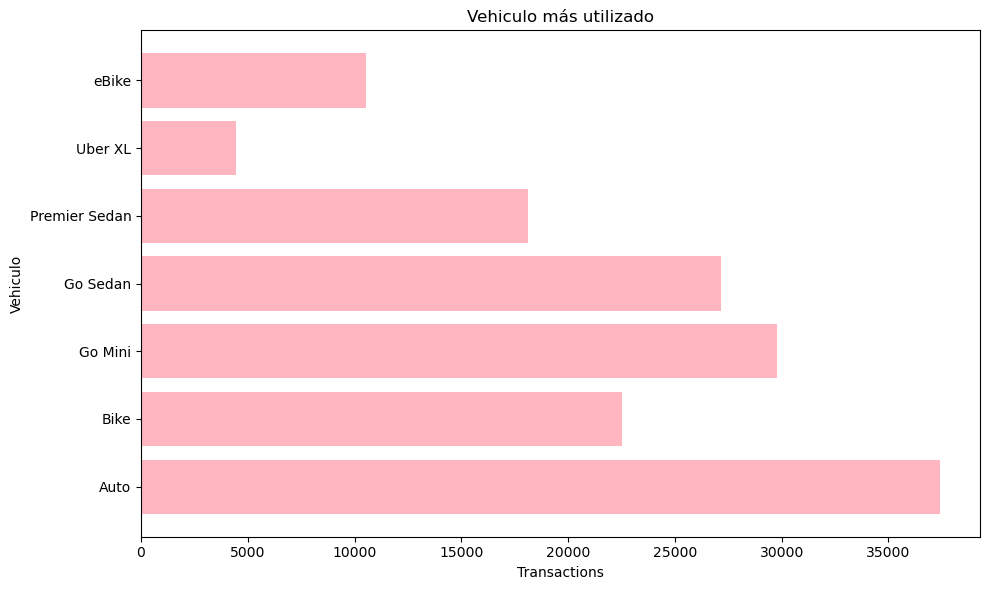

In [35]:
vehycle_values = df_uber.groupby(['Vehicle Type'], as_index = False)['Customer ID'].count()

plt.figure(figsize = (10,6))
plt.barh(vehycle_values['Vehicle Type'], vehycle_values['Customer ID'], color = 'lightpink')
plt.title('Vehiculo más utilizado')
plt.xlabel('Transactions')
plt.ylabel('Vehiculo')
plt.tight_layout()
plt.show()

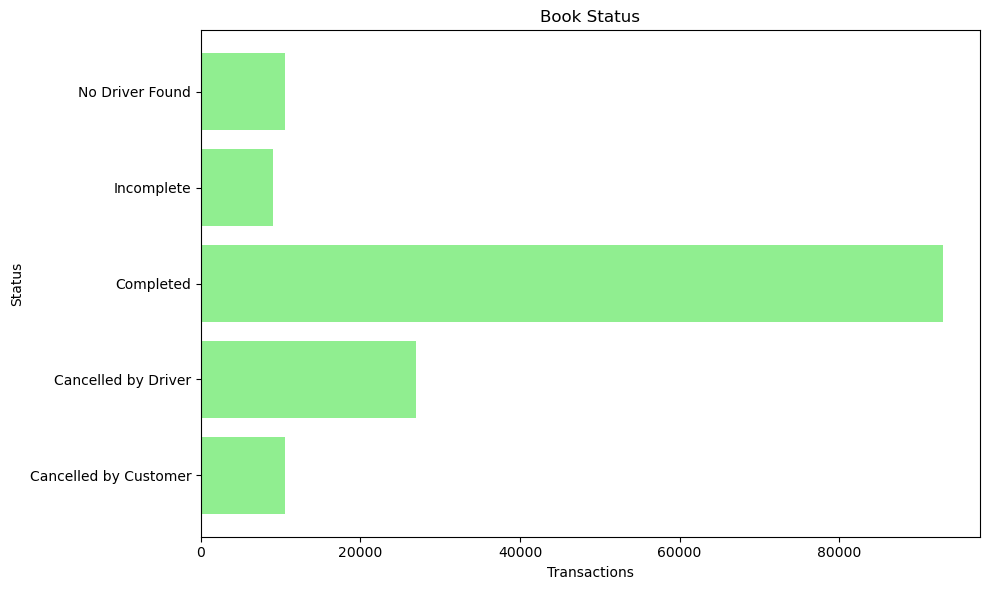

In [52]:
booking_values = df_uber.groupby(['Booking Status'], as_index = False)['Customer ID'].count()

plt.figure(figsize = (10,6))
plt.barh(booking_values['Booking Status'], booking_values['Customer ID'], color = 'lightgreen')
plt.title('Book Status')
plt.xlabel('Transactions')
plt.ylabel('Status')
plt.tight_layout()
plt.show()

In [46]:
precios = df_uber[df_uber['Booking Status'] == 'Completed']['Booking Value'].dropna()

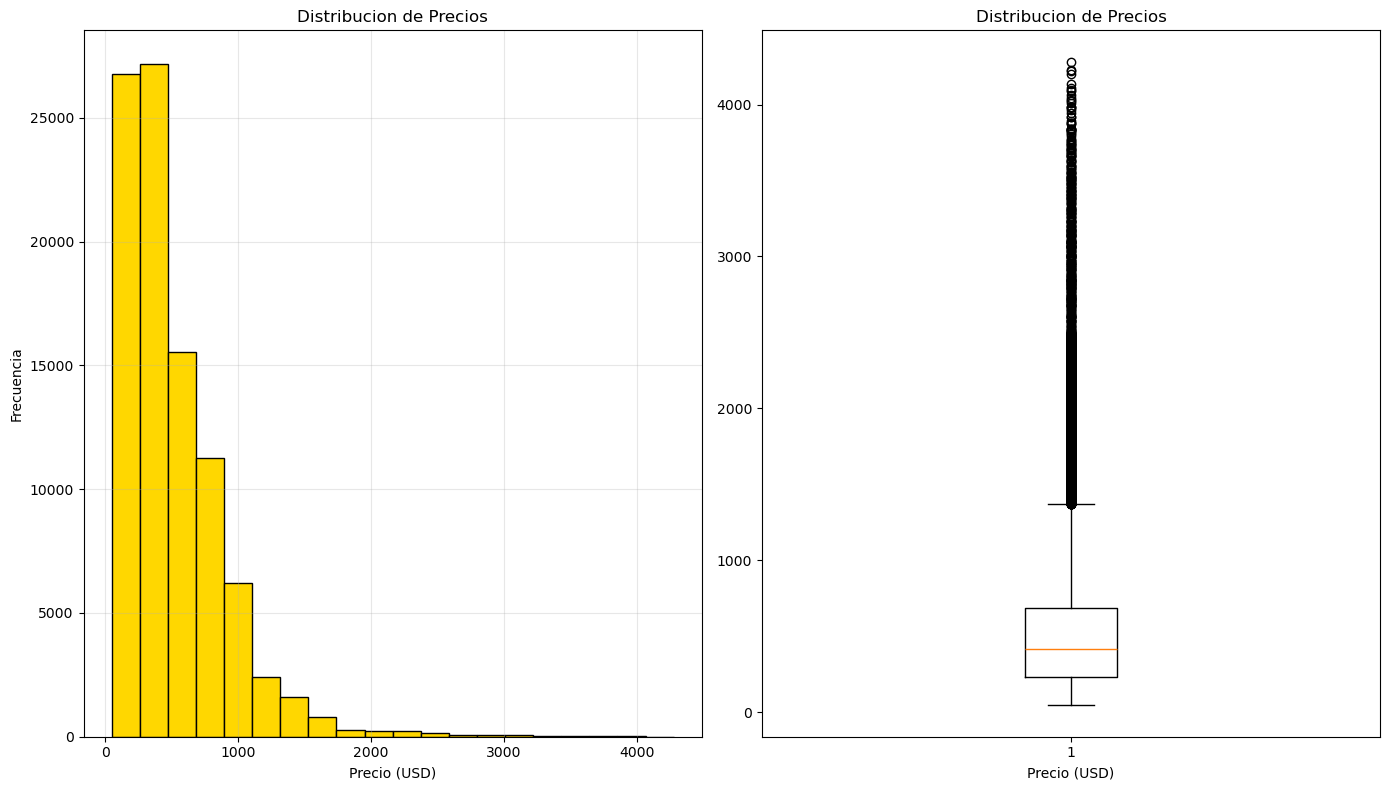

In [40]:
plt.figure(figsize = (14, 8))

plt.subplot(1, 2, 1)
plt.hist(precios, bins = 20, color = 'gold', edgecolor = 'black')
plt.title('Distribucion de Precios')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.grid(alpha = 0.3)

plt.subplot(1, 2, 2)
plt.boxplot(precios)
plt.title('Distribucion de Precios')
plt.xlabel('Precio (USD)')

plt.tight_layout()
plt.show()

In [59]:
# Correlacion entre precio y distancia
datos = df_uber[df_uber['Booking Status'] == 'Completed'].dropna(subset = ['Booking Value', 'Ride Distance'])

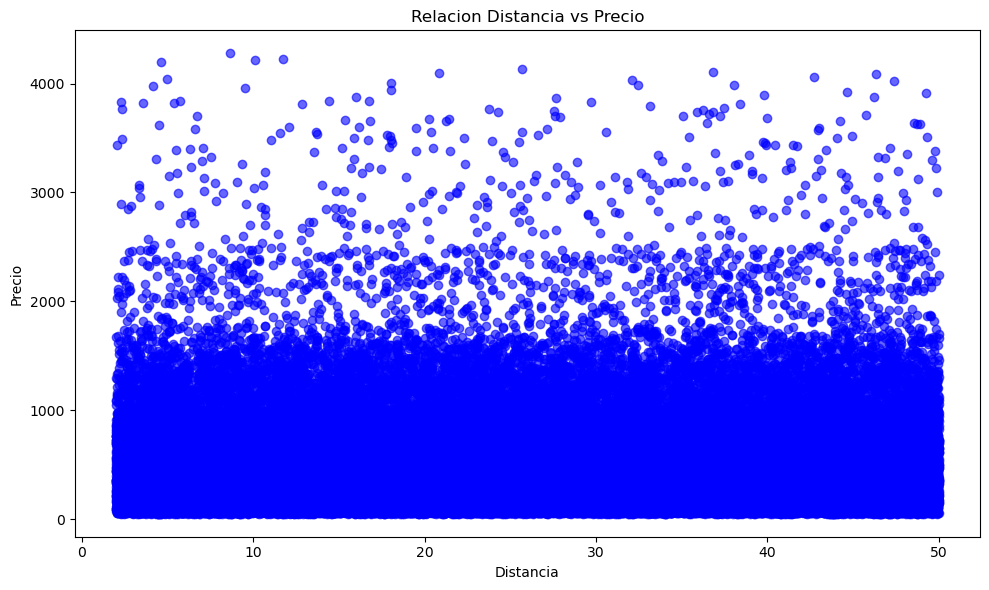

In [61]:
plt.figure(figsize = (10,6))
plt.scatter(datos['Ride Distance'], datos['Booking Value'], alpha = 0.6, color = 'blue')
plt.title('Relacion Distancia vs Precio')
plt.xlabel('Distancia')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

In [63]:
datos['Ride Distance'].corr(datos['Booking Value']) * 100

np.float64(0.5668006166115629)